In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.transforms import v2
import os
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [13]:
# --- 1. KONFİGÜRASYON AYARLARI ---

# Cihazı ayarla (GPU varsa GPU, yoksa CPU kullan)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Kullanılan Cihaz: {DEVICE}")

# Veri setinin ana klasörü
DATA_DIR = "train_dataset"

# Model eğitimi için temel parametreler
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 30

# TAHMİN EŞİĞİ (THRESHOLD)
PREDICTION_THRESHOLD = 0.5

Kullanılan Cihaz: cuda


In [14]:
# --- 2. VERİ DÖNÜŞÜMLERİ (TRANSFORMS) ---

# Veri çoğaltma (augmentation) ve normalizasyon işlemleri
# EĞİTİM setine uygulanacak dönüşümler:
# Modelin her epoch'ta resmin farklı bir versiyonunu görmesini sağlar, ezberlemeyi önler.
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # %50 ihtimalle resmi yatayda çevir
    transforms.RandomRotation(10), # -10 ile +10 derece arasında rastgele döndür
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomApply([v2.JPEG(quality=(60, 100))], p=0.5),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))], p=0.3),
    transforms.ToTensor(), # Resmi PyTorch tensörüne çevir (Piksel değerlerini 0-1 arasına getirir)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet istatistikleri ile normalleştir
])

# VALIDATION ve TEST setlerine uygulanacak dönüşümler:
# Bu setlerde veri çoğaltma yapılmaz, çünkü modelin performansı tutarlı verilerle ölçülmelidir.
val_test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [15]:
# --- 3. VERİ YÜKLEYİCİLER (DATALOADERS) ---

# ImageFolder, klasör isimlerine göre etiketleri otomatik olarak atar (örn: fake=0, real=1)
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transforms)
validation_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "validation"), transform=val_test_transforms)
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_test_transforms)

# Verileri batch'ler halinde modele sunmak için DataLoader'lar oluşturulur
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
validation_loader = DataLoader(dataset=validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("\nVeri Seti Bilgileri:")
print(f"Eğitim seti: {len(train_dataset)} resim")
print(f"Doğrulama seti: {len(validation_dataset)} resim")
print(f"Test seti: {len(test_dataset)} resim")
print(f"Sınıflar: {train_dataset.classes}")


Veri Seti Bilgileri:
Eğitim seti: 35979 resim
Doğrulama seti: 11984 resim
Test seti: 11996 resim
Sınıflar: ['fake', 'real']


In [16]:
# --- 4. MODEL TANIMLAMALARI ---

# Seçenek 1: Kendi yazdığım CNN modeli
class KendiCNN(nn.Module):
    def __init__(self):
        super(KendiCNN, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# Seçenek 2: Hazır bir model (ResNet18) ve Transfer Learning
def get_pretrained_model():
    # ImageNet üzerinde eğitilmiş ResNet18 modelini yükle
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # Önceden eğitilmiş konvolüsyon katmanlarının ağırlıklarını dondur (Aşırı öğrenmeyi engeller)
    for param in model.parameters():
        param.requires_grad = False

    # SADECE layer4'ü eğitime aç (AI/Real ayrımı için ince özellikleri öğrenebilmesi adına)
    for param in model.layer4.parameters():
        param.requires_grad = True
    
    # Modelin son katmanını (classifier) kendi problemimize göre değiştir
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.6), # Aşırı öğrenmeyi (overfitting) engellemek için Dropout eklendi
        nn.Linear(num_ftrs, 1) # Çıktıyı 1 yap (binary classification)
    )
    
    return model

In [17]:
# --- 5. EĞİTİM FONKSİYONU ---

def train_model(model, criterion, optimizer, train_loader, val_loader, epochs, model_save_path, scheduler=None):
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        start_time = time.time()
        
        # --- Eğitim Aşaması ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Eğitim]"):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE).float().unsqueeze(1)
            
            # set_to_none=True ile bellek temizliği hızlandırıldı
            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            
            # Doğruluk hesaplama (Eşik değeri standart 0.5)
            predicted = torch.sigmoid(outputs) > PREDICTION_THRESHOLD
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct_train / total_train

        # --- Doğrulama Aşaması ---
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Doğrulama]"):
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE).float().unsqueeze(1)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

                predicted = torch.sigmoid(outputs) > PREDICTION_THRESHOLD
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = correct_val / total_val
        
        # Metrikleri history sözlüğüne kaydet
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Eğer bir scheduler (zamanlayıcı) verildiyse, doğrulama kaybına bakarak adım at
        if scheduler is not None:
            scheduler.step(val_loss)
        
        end_time = time.time()
        epoch_duration = end_time - start_time

        print(f"Epoch {epoch+1}/{epochs} | Süre: {epoch_duration:.2f}s")
        print(f"Eğitim Loss: {epoch_loss:.4f} | Eğitim Acc: {epoch_acc:.4f}")
        print(f"Doğrulama Loss: {val_loss:.4f} | Doğrulama Acc: {val_acc:.4f}\n")

        # En iyi modeli kaydet
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), model_save_path)
            print(f"*** Yeni en iyi model kaydedildi: {model_save_path} (Doğrulama Acc: {best_val_acc:.4f}) ***\n")

    print("Eğitim tamamlandı.")
    return model_save_path, history

def plot_training_history(history, model_name="Model"):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # 1. Grafik: Loss (Kayıp) Değişimi
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Eğitim Loss', linewidth=2)
    plt.plot(epochs, history['val_loss'], 'r-', label='Doğrulama Loss', linewidth=2)
    plt.title(f'{model_name} - Eğitim ve Doğrulama Kaybı (Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. Grafik: Accuracy (Başarım) Değişimi
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Eğitim Accuracy', linewidth=2)
    plt.plot(epochs, history['val_acc'], 'r-', label='Doğrulama Accuracy', linewidth=2)
    plt.title(f'{model_name} - Eğitim ve Doğrulama Başarımı (Accuracy)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [18]:
# --- 6. TEST FONKSİYONU VE METRİKLER ---

def test_model(model, model_path, test_loader, class_names):
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.to(DEVICE)
    model.eval()

    y_true = []
    y_pred = []
    
    print("\n--- Test Aşaması Başlatıldı ---")
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="[Test]"):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            
            predicted = torch.sigmoid(outputs) > PREDICTION_THRESHOLD

            # squeeze() yerine view(-1) kullanarak son batch 1 gelse bile çökmesini engelliyoruz
            y_true.extend(labels.cpu().view(-1).numpy())
            y_pred.extend(predicted.cpu().view(-1).numpy())

    print("\n--- Test Sonuçları ---")
    
    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Test Seti Başarımı (Accuracy): {accuracy:.4f}\n")

    # Classification Report (Precision, Recall, F1-Score)
    print("Sınıflandırma Raporu:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Karmaşıklık Matrisi (Confusion Matrix)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
    plt.ylabel('Gerçek Etiket')
    plt.xlabel('Tahmin Edilen Etiket')
    plt.show()


==================== MODEL EĞİTİMİ BAŞLIYOR: CUSTOM ====================


Epoch 1/30 [Doğrulama]: 100%|██████████| 375/375 [04:17<00:00,  1.46it/s]


Epoch 1/30 | Süre: 1485.52s
Eğitim Loss: 0.5321 | Eğitim Acc: 0.7032
Doğrulama Loss: 0.6323 | Doğrulama Acc: 0.6671

*** Yeni en iyi model kaydedildi: train_dataset\best_model_custom.pth (Doğrulama Acc: 0.6671) ***



Epoch 2/30 [Doğrulama]: 100%|██████████| 375/375 [00:45<00:00,  8.23it/s]


Epoch 2/30 | Süre: 377.92s
Eğitim Loss: 0.4816 | Eğitim Acc: 0.7432
Doğrulama Loss: 0.4441 | Doğrulama Acc: 0.7694

*** Yeni en iyi model kaydedildi: train_dataset\best_model_custom.pth (Doğrulama Acc: 0.7694) ***



...

Epoch 28/30 | Süre: 415.72s
Eğitim Loss: 0.3094 | Eğitim Acc: 0.8557
Doğrulama Loss: 0.2706 | Doğrulama Acc: 0.8798



Epoch 29/30 [Doğrulama]: 100%|██████████| 375/375 [00:49<00:00,  7.63it/s]


Epoch 29/30 | Süre: 419.35s
Eğitim Loss: 0.3022 | Eğitim Acc: 0.8599
Doğrulama Loss: 0.2552 | Doğrulama Acc: 0.8859

*** Yeni en iyi model kaydedildi: train_dataset\best_model_custom.pth (Doğrulama Acc: 0.8859) ***



Epoch 30/30 [Doğrulama]: 100%|██████████| 375/375 [00:47<00:00,  7.97it/s]


Epoch 30/30 | Süre: 411.09s
Eğitim Loss: 0.2981 | Eğitim Acc: 0.8615
Doğrulama Loss: 0.2559 | Doğrulama Acc: 0.8858

Eğitim tamamlandı.


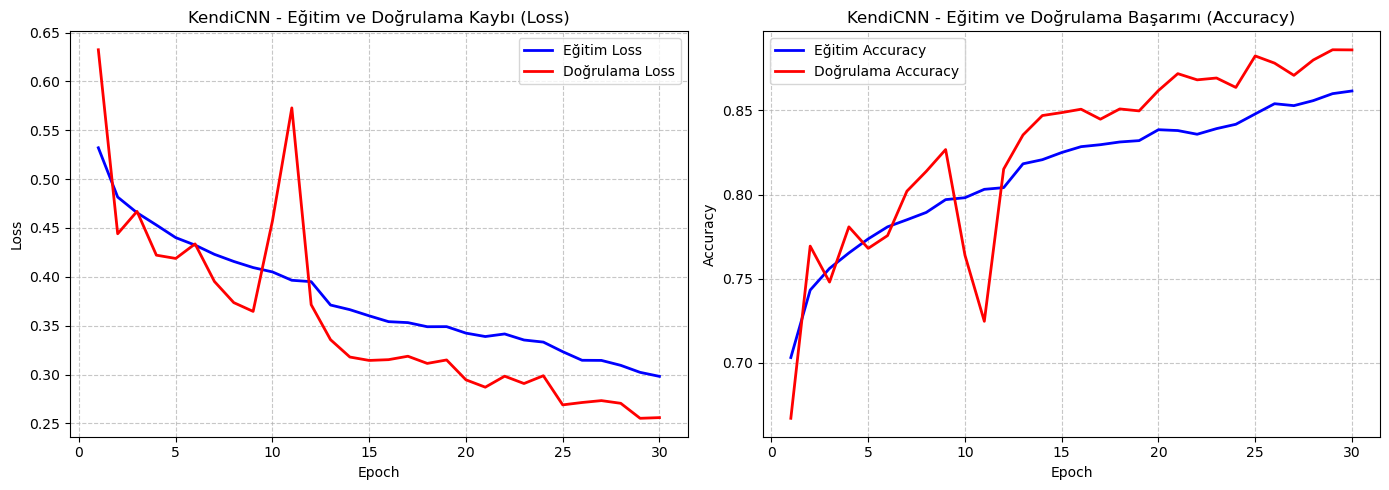


==================== MODEL EĞİTİMİ TAMAMLANDI: CUSTOM ====================


In [ ]:
# --- 7. ÖZEL CNN MODELİNİN EĞİTİLMESİ (KendiCNN) ---

print(f"\n{'='*20} MODEL EĞİTİMİ BAŞLIYOR: CUSTOM {'='*20}")

custom_model = KendiCNN().to(DEVICE)
 
# pozitif sınıf (Real) ağırlığını 0.85'e düşürüyoruz.
custom_weight = torch.tensor([0.85]).to(DEVICE)
custom_criterion = nn.BCEWithLogitsLoss(pos_weight=custom_weight)
custom_optimizer = optim.Adam(custom_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
custom_scheduler = optim.lr_scheduler.ReduceLROnPlateau(custom_optimizer, mode='min', factor=0.5, patience=2)

custom_model_path, custom_history = train_model(
    custom_model, custom_criterion, custom_optimizer,
    train_loader, validation_loader,
    EPOCHS, os.path.join(DATA_DIR, "best_model_custom.pth"),
    scheduler=custom_scheduler
)

# Eğitimi biten modelin grafiklerini çizdir
plot_training_history(custom_history, model_name="KendiCNN")

print(f"\n{'='*20} MODEL EĞİTİMİ TAMAMLANDI: CUSTOM {'='*20}")


==================== MODEL EĞİTİMİ BAŞLIYOR: PRETRAINED ====================


Epoch 1/8 [Doğrulama]: 100%|██████████| 375/375 [00:46<00:00,  8.08it/s]


Epoch 1/8 | Süre: 378.51s
Eğitim Loss: 0.4463 | Eğitim Acc: 0.7905
Doğrulama Loss: 0.3212 | Doğrulama Acc: 0.8616

*** Yeni en iyi model kaydedildi: train_dataset\best_model_pretrained.pth (Doğrulama Acc: 0.8616) ***



Epoch 2/8 [Doğrulama]: 100%|██████████| 375/375 [00:45<00:00,  8.18it/s]


Epoch 2/8 | Süre: 379.41s
Eğitim Loss: 0.3422 | Eğitim Acc: 0.8495
Doğrulama Loss: 0.2727 | Doğrulama Acc: 0.8858

*** Yeni en iyi model kaydedildi: train_dataset\best_model_pretrained.pth (Doğrulama Acc: 0.8858) ***



...

Epoch 6/8 | Süre: 382.87s
Eğitim Loss: 0.2406 | Eğitim Acc: 0.9012
Doğrulama Loss: 0.2238 | Doğrulama Acc: 0.9115

*** Yeni en iyi model kaydedildi: train_dataset\best_model_pretrained.pth (Doğrulama Acc: 0.9115) ***



Epoch 7/8 [Doğrulama]: 100%|██████████| 375/375 [00:45<00:00,  8.33it/s]


Epoch 7/8 | Süre: 381.39s
Eğitim Loss: 0.2252 | Eğitim Acc: 0.9077
Doğrulama Loss: 0.2183 | Doğrulama Acc: 0.9159

*** Yeni en iyi model kaydedildi: train_dataset\best_model_pretrained.pth (Doğrulama Acc: 0.9159) ***



Epoch 8/8 [Doğrulama]: 100%|██████████| 375/375 [00:46<00:00,  8.05it/s]


Epoch 8/8 | Süre: 385.54s
Eğitim Loss: 0.2104 | Eğitim Acc: 0.9156
Doğrulama Loss: 0.2104 | Doğrulama Acc: 0.9186

*** Yeni en iyi model kaydedildi: train_dataset\best_model_pretrained.pth (Doğrulama Acc: 0.9186) ***

Eğitim tamamlandı.


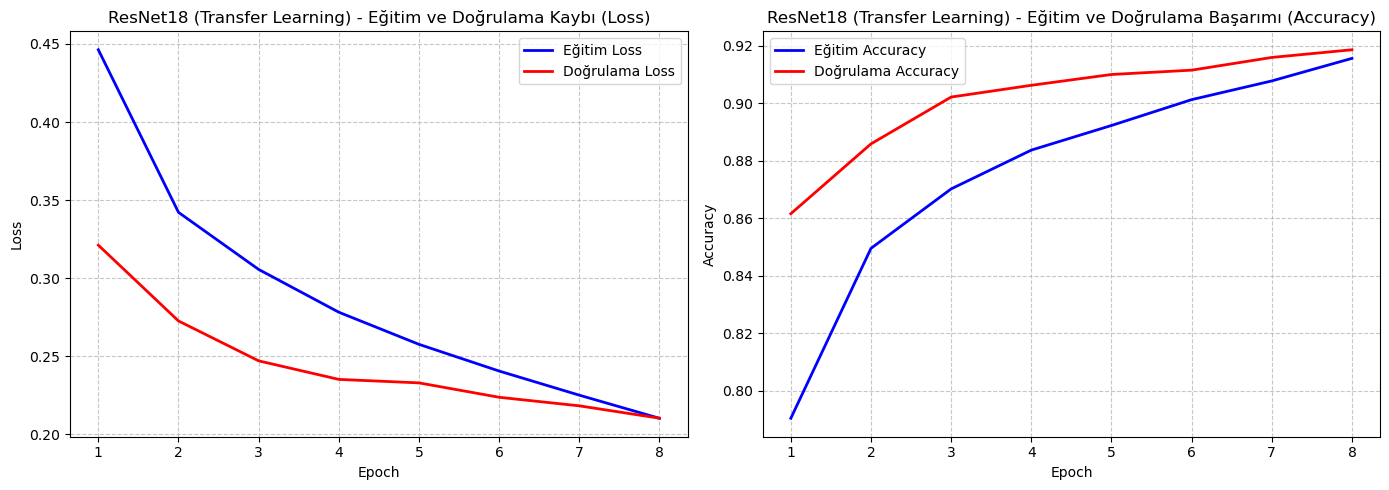


==================== MODEL EĞİTİMİ TAMAMLANDI: PRETRAINED ====================


In [9]:
# --- 8. HAZIR MODELİN EĞİTİLMESİ (ResNet18) ---

torch.cuda.empty_cache()

print(f"\n{'='*20} MODEL EĞİTİMİ BAŞLIYOR: PRETRAINED {'='*20}")

pretrained_model = get_pretrained_model().to(DEVICE)

pretrained_criterion = nn.BCEWithLogitsLoss()

# Differential Learning Rates (Farklı Öğrenme Oranları)
# layer4 için ÇOK DÜŞÜK, fc (yeni sınıflandırıcı) için NORMAL öğrenme oranı uyguluyoruz.
layer4_params = []
fc_params = []
for name, param in pretrained_model.named_parameters():
    if param.requires_grad:
        if 'layer4' in name:
            layer4_params.append(param)
        elif 'fc' in name:
            fc_params.append(param)

pretrained_optimizer = optim.Adam([
    {'params': layer4_params, 'lr': 1e-5},  # Backbone kısmına çok küçük LR (Overfitting'i önler)
    {'params': fc_params, 'lr': 0.0005} # Sınıflandırıcıya normal LR
], weight_decay=1e-3)
pretrained_scheduler = optim.lr_scheduler.ReduceLROnPlateau(pretrained_optimizer, mode='min', factor=0.5, patience=2)

pretrained_model_path, pretrained_history = train_model(
    pretrained_model, pretrained_criterion, pretrained_optimizer,
    train_loader, validation_loader,
    8, os.path.join(DATA_DIR, "best_model_pretrained.pth"),
    scheduler=pretrained_scheduler
)

# Eğitimi biten modelin grafiklerini çizdir
plot_training_history(pretrained_history, model_name="ResNet18 (Transfer Learning)")

print(f"\n{'='*20} MODEL EĞİTİMİ TAMAMLANDI: PRETRAINED {'='*20}")



######################### KAYITLI MODELLERİN TEST SONUÇLARI #########################

--- Test Edilen Model: CUSTOM ---

--- Test Aşaması Başlatıldı ---


[Test]: 100%|██████████| 375/375 [00:40<00:00,  9.34it/s]



--- Test Sonuçları ---
Test Seti Başarımı (Accuracy): 0.8870

Sınıflandırma Raporu:
              precision    recall  f1-score   support

        fake       0.89      0.88      0.89      5996
        real       0.88      0.89      0.89      6000

    accuracy                           0.89     11996
   macro avg       0.89      0.89      0.89     11996
weighted avg       0.89      0.89      0.89     11996



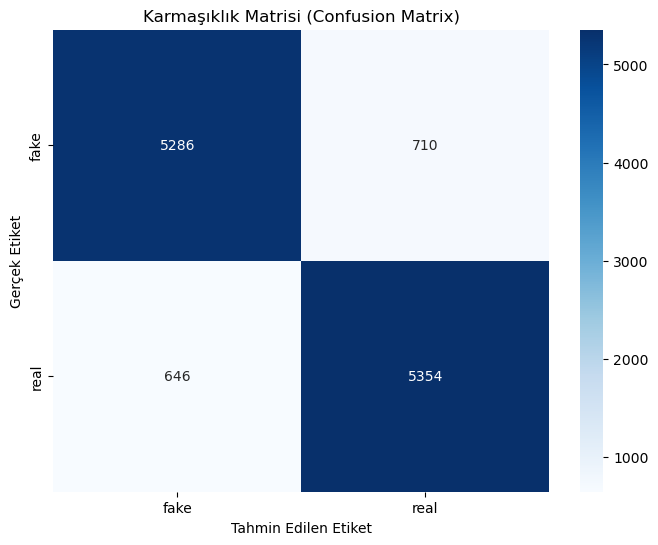


--- Test Edilen Model: PRETRAINED ---

--- Test Aşaması Başlatıldı ---


[Test]: 100%|██████████| 375/375 [00:59<00:00,  6.35it/s]



--- Test Sonuçları ---
Test Seti Başarımı (Accuracy): 0.9216

Sınıflandırma Raporu:
              precision    recall  f1-score   support

        fake       0.92      0.93      0.92      5996
        real       0.93      0.91      0.92      6000

    accuracy                           0.92     11996
   macro avg       0.92      0.92      0.92     11996
weighted avg       0.92      0.92      0.92     11996



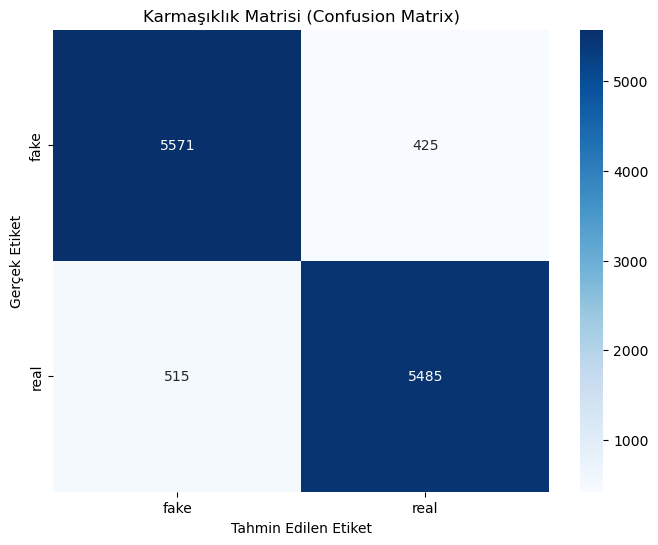

In [19]:
# --- 9. TEST VE SONUÇLARIN GÖSTERİLMESİ ---

print(f"\n\n{'#'*25} KAYITLI MODELLERİN TEST SONUÇLARI {'#'*25}")

# Rapor ve matriste kullanılacak sınıf isimlerini veri setinden al
class_names = train_dataset.classes

models_for_evaluation = [
    {
        "name": "custom",
        "get_model": KendiCNN,
        "path": os.path.join(DATA_DIR, "best_model_custom.pth")
    },
    {
        "name": "pretrained",
        "get_model": get_pretrained_model,
        "path": os.path.join(DATA_DIR, "best_model_pretrained.pth")
    }
]

for model_info in models_for_evaluation:
    # Modelin ağırlık dosyası var mı diye kontrol et
    if not os.path.exists(model_info["path"]):
        print(f"\n--- UYARI: Model dosyası bulunamadı, atlanıyor: {model_info['path']} ---")
        continue

    print(f"\n--- Test Edilen Model: {model_info['name'].upper()} ---")
    
    # Test için yeni bir model nesnesi oluştur ve en iyi ağırlıkları yükle
    test_model_instance = model_info["get_model"]()
    
    test_model(test_model_instance, model_info["path"], test_loader, class_names)

In [20]:
# --- 10. TEK BİR RESMİ TEST ETME (SINGLE IMAGE PREDICTION) ---

from PIL import Image

PREDICT_MODELS = [
    {
        "name": "custom",
        "get_model": KendiCNN,
        "path": os.path.join(DATA_DIR, "best_model_custom.pth")
    },
    {
        "name": "pretrained",
        "get_model": get_pretrained_model,
        "path": os.path.join(DATA_DIR, "best_model_pretrained.pth")
    }
]

CLASS_NAMES = ["fake", "real"]

def predict_single_image(image_path, models_info, class_names):
    if not os.path.exists(image_path):
        print(f"\nHata: Resim bulunamadı -> {image_path}")
        return

    try:
        img = Image.open(image_path).convert("RGB")
        
        transform = transforms.Compose([
            transforms.Resize((256, 256), Image.Resampling.LANCZOS),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        img_tensor = transform(img).unsqueeze(0).to(DEVICE)
        
        print(f"\n--- Tekil Resim Test Sonucu ---")
        print(f"Resim: {image_path}")
        print(f"{'Model':<15} | {'Tahmin':<10} | {'Güven Skoru'}")
        print("-" * 50)
        
        for model_info in models_info:
            model_name = model_info["name"].upper()
            model_path = model_info["path"]
            get_model_fn = model_info["get_model"]

            if not os.path.exists(model_path):
                print(f"{model_name:<15} | HATA: Model bulunamadı ({model_path})")
                continue

            # Modeli yükle
            model = get_model_fn()
            model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
            model.to(DEVICE)
            model.eval()
            
            with torch.no_grad():
                output = model(img_tensor)
                prob = torch.sigmoid(output).item()
                predicted_class = 1 if prob > PREDICTION_THRESHOLD else 0
                
            predicted_label = class_names[predicted_class]
            confidence = prob if predicted_class == 1 else 1 - prob
            
            print(f"{model_name:<15} | {predicted_label.upper():<10} | %{confidence*100:.2f}")
            
        print("-" * 50)
        
    except Exception as e:
        print(f"Resim işlenirken hata oluştu: {e}")

ornek_resim_yolu = "deneme/aasa.png"
predict_single_image(ornek_resim_yolu, PREDICT_MODELS, CLASS_NAMES)


--- Tekil Resim Test Sonucu ---
Resim: deneme/aasa.png
Model           | Tahmin     | Güven Skoru
--------------------------------------------------
CUSTOM          | FAKE       | %99.73
PRETRAINED      | FAKE       | %100.00
--------------------------------------------------




######################### KLASİK ML MODELLERİ BAŞLIYOR (SVM & KNN) #########################

Eğitim verileri SVM/KNN için hazırlanıyor...


Özellikler Çıkarılıyor: 100%|██████████| 1125/1125 [07:00<00:00,  2.67it/s]


Test verileri SVM/KNN için hazırlanıyor...


Özellikler Çıkarılıyor: 100%|██████████| 375/375 [00:26<00:00, 13.96it/s]



--- Veri Ölçeklendirme ve Boyut İndirgeme (PCA) Uygulanıyor ---
Orijinal Özellik Sayısı (Ham Pikseller): 3072
PCA Sonrası İndirgenmiş Özellik Sayısı: 195

--- KNN Modeli Eğitiliyor ---
KNN Test Ediliyor...

--- KNN Sonuçları ---
Test Seti Başarımı (Accuracy): 0.5899

Sınıflandırma Raporu:
              precision    recall  f1-score   support

        fake       0.75      0.27      0.40      5996
        real       0.56      0.91      0.69      6000

    accuracy                           0.59     11996
   macro avg       0.65      0.59      0.54     11996
weighted avg       0.65      0.59      0.54     11996



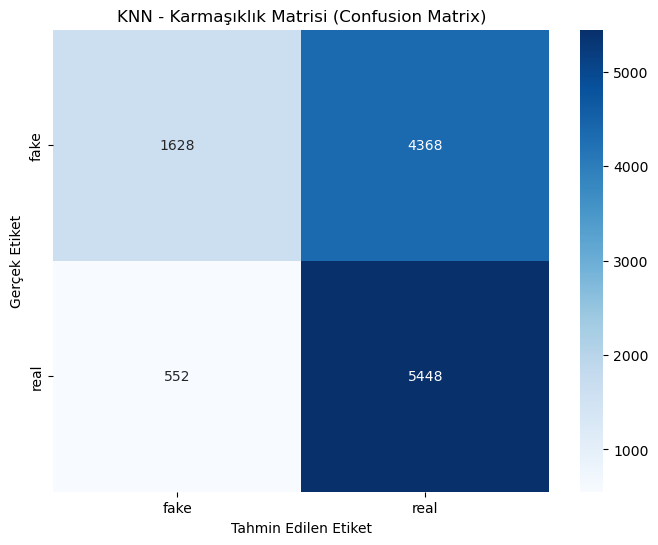


--- SVM Modeli Eğitiliyor (Bu işlem veri boyutuna göre biraz zaman alabilir) ---
[LibLinear]SVM Test Ediliyor...

--- SVM Sonuçları ---
Test Seti Başarımı (Accuracy): 0.6180

Sınıflandırma Raporu:
              precision    recall  f1-score   support

        fake       0.62      0.63      0.62      5996
        real       0.62      0.61      0.61      6000

    accuracy                           0.62     11996
   macro avg       0.62      0.62      0.62     11996
weighted avg       0.62      0.62      0.62     11996



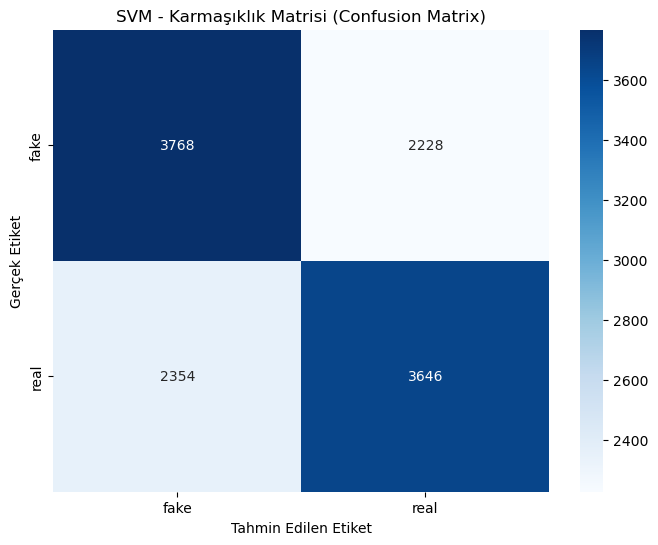

['train_dataset\\best_model_svm.pkl']

In [12]:
# --- 11. KLASİK MAKİNE ÖĞRENMESİ MODELLERİ (SVM & KNN) ---

print(f"\n\n{'#'*25} KLASİK ML MODELLERİ BAŞLIYOR (SVM & KNN) {'#'*25}")

os.environ["LOKY_MAX_CPU_COUNT"] = "4"

# Geleneksel ML modelleri için 256x256 çok büyük (196.608 özellik).
# Eğitim hızını artırmak ve RAM'i korumak için boyutları 32x32'ye küçültüp düzleştirerek (flatten) eğiteceğiz.
ml_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

# Sadece eğitim ve test setlerini klasik ML için yeniden yüklüyoruz
ml_train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=ml_transforms)
ml_test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=ml_transforms)

# Scikit-learn modelleri tüm veriyi tek bir 2D matris olarak (Örnek Sayısı x Özellik Sayısı) ister
def extract_features_for_ml(dataset):
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    X = []
    y = []
    for inputs, labels in tqdm(loader, desc="Özellikler Çıkarılıyor"):
        # Resimleri düzleştir (flatten): (Batch, 3, 32, 32) -> (Batch, 3072)
        inputs_flattened = inputs.view(inputs.size(0), -1).numpy()
        X.extend(inputs_flattened)
        y.extend(labels.numpy())
    return np.array(X), np.array(y)

print("\nEğitim verileri SVM/KNN için hazırlanıyor...")
X_train, y_train = extract_features_for_ml(ml_train_dataset)
print("Test verileri SVM/KNN için hazırlanıyor...")
X_test, y_test = extract_features_for_ml(ml_test_dataset)

print("\n--- Veri Ölçeklendirme ve Boyut İndirgeme (PCA) Uygulanıyor ---")
# 1. Verileri Ölçeklendir (Ortalama 0, Varyans 1 olacak şekilde)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. PCA ile boyutu küçült (Örn: 3072 boyuttan en önemli 150 özelliği çıkar)
# Bu işlem "Curse of Dimensionality"i çözer ve SVM/KNN modellerini inanılmaz hızlandırır.
pca = PCA(n_components=0.95, random_state=42) # Orijinal bilginin (varyansın) %95'ini koru
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Orijinal Özellik Sayısı (Ham Pikseller): {X_train.shape[1]}")
print(f"PCA Sonrası İndirgenmiş Özellik Sayısı: {X_train_pca.shape[1]}")
joblib.dump(scaler, os.path.join(DATA_DIR, "scaler.pkl")) # Test aşaması için kaydet
joblib.dump(pca, os.path.join(DATA_DIR, "pca.pkl")) # Test aşaması için kaydet

def evaluate_ml_model(y_true, y_pred, model_name, class_names):
    print(f"\n--- {model_name} Sonuçları ---")
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Test Seti Başarımı (Accuracy): {accuracy:.4f}\n")
    
    print("Sınıflandırma Raporu:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Karmaşıklık Matrisi (Confusion Matrix)')
    plt.ylabel('Gerçek Etiket')
    plt.xlabel('Tahmin Edilen Etiket')
    plt.show()

# 1. KNN Modeli
print("\n--- KNN Modeli Eğitiliyor ---")
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=2)
knn_model.fit(X_train_pca, y_train)

print("KNN Test Ediliyor...")
y_pred_knn = knn_model.predict(X_test_pca)
evaluate_ml_model(y_test, y_pred_knn, "KNN", train_dataset.classes)
joblib.dump(knn_model, os.path.join(DATA_DIR, "best_model_knn.pkl")) # Modeli Kaydet

# 2. SVM Modeli
print("\n--- SVM Modeli Eğitiliyor (Bu işlem veri boyutuna göre biraz zaman alabilir) ---")
svm_model = LinearSVC(random_state=42, verbose=1, dual=False, max_iter=2000)
svm_model.fit(X_train_pca, y_train)

print("SVM Test Ediliyor...")
y_pred_svm = svm_model.predict(X_test_pca)
evaluate_ml_model(y_test, y_pred_svm, "SVM", train_dataset.classes)
joblib.dump(svm_model, os.path.join(DATA_DIR, "best_model_svm.pkl")) # Modeli Kaydet

In [13]:
# --- 12. KLASİK ML MODELLERİ İLE TEK BİR RESMİ TEST ETME ---

from PIL import Image

def predict_single_image_ml(image_path, class_names):
    if not os.path.exists(image_path):
        print(f"\nHata: Resim bulunamadı -> {image_path}")
        return

    try:
        # 1. Kayıtlı dönüştürücüleri (Scaler ve PCA) yükle
        scaler_path = os.path.join(DATA_DIR, "scaler.pkl")
        pca_path = os.path.join(DATA_DIR, "pca.pkl")
        
        if not os.path.exists(scaler_path) or not os.path.exists(pca_path):
            print("\nHata: Scaler veya PCA modeli bulunamadı. Lütfen önce 11. adımı çalıştırıp kaydedin.")
            return
            
        scaler = joblib.load(scaler_path)
        pca = joblib.load(pca_path)
        
        # 2. Resmi yükle ve ML formatına uygun ön işleme yap (32x32 boyutlandırma)
        img = Image.open(image_path).convert("RGB")
        
        ml_transform = transforms.Compose([
            transforms.Resize((32, 32)),
            transforms.ToTensor()
        ])
        
        # Resmi PyTorch tensörüne çevir ve düzleştir (Flatten): (1, 3, 32, 32) -> (1, 3072)
        img_tensor = ml_transform(img)
        img_flattened = img_tensor.view(1, -1).numpy()
        
        # 3. Ölçeklendirme ve Boyut İndirgeme (SADECE transform yapıyoruz, fit YAPMIYORUZ!)
        img_scaled = scaler.transform(img_flattened)
        img_pca = pca.transform(img_scaled)
        
        print(f"\n--- ML Modelleri Tekil Resim Test Sonucu ---")
        print(f"Resim: {image_path}")
        print(f"{'Model':<15} | {'Tahmin':<10}")
        print("-" * 30)
        
        # 4. Modelleri yükle ve tahmin et
        ml_models = [("KNN", "best_model_knn.pkl"), ("SVM", "best_model_svm.pkl")]
        
        for model_name, pkl_name in ml_models:
            model_path = os.path.join(DATA_DIR, pkl_name)
            if os.path.exists(model_path):
                model = joblib.load(model_path)
                predicted_class = model.predict(img_pca)[0] # Tahmin sonucunu al (örn: 0 veya 1)
                print(f"{model_name:<15} | {class_names[predicted_class].upper():<10}")
            else:
                print(f"{model_name:<15} | HATA: Model dosyası bulunamadı")
        print("-" * 30)
    except Exception as e:
        print(f"Resim işlenirken hata oluştu: {e}")

ornek_resim_yolu = "deneme/aasa.png"
predict_single_image_ml(ornek_resim_yolu, train_dataset.classes)


--- ML Modelleri Tekil Resim Test Sonucu ---
Resim: deneme/aasa.png
Model           | Tahmin    
------------------------------
KNN             | FAKE      
SVM             | FAKE      
------------------------------
